<a href="https://colab.research.google.com/github/narender5162/Customer-Segmentation-Retention-Analysis/blob/main/Customer_Segmentation_Pipeline_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!git https://github.com/narender5162/Customer-Segmentation-Retention-Analysis.git


git: 'https://github.com/narender5162/Customer-Segmentation-Retention-Analysis.git' is not a git command. See 'git --help'.


In [31]:
# Import Libraries

import pandas as pd         # For data manipulation, cleaning, and aggregation
import numpy as np          # For numerical operations and vectorization
import datetime as dt       # For parsing and manipulating transaction dates

# For exploratory data checking and backend visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for the notebook plots
sns.set_theme(style="whitegrid")
%matplotlib inline

In [32]:
#  Mount Google Drive & Load Dataset

from google.colab import drive
import pandas as pd

# Mount your Google Drive into the Colab environment
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
#Define the path to where you saved the file in your Google Drive
file_path ='/content/drive/MyDrive/OnlineRetail.csv.zip'

In [34]:
# Load the dataset with correct encoding and date parsing
try:
    df = pd.read_csv(
        file_path,
        encoding='latin-1',
        parse_dates=['InvoiceDate']
    )
    print("Dataset loaded successfully!\n")
except FileNotFoundError:
    print(f"Error: Could not find the file at {file_path}.")
    print("Please check that the folder name and file name in your Google Drive match exactly.")

# Quick Overview of the Raw Data

print(f'Shape of the dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print('-' * 40)

print('Column Data Types:')
print(df.dtypes)
print('-' * 40)

print('Missing Values Per Column:')
print(df.isnull().sum())
print('-' * 40)

print('First 5 Rows of Raw Data:')
display(df.head())

Dataset loaded successfully!

Shape of the dataset: 541,909 rows, 8 columns
----------------------------------------
Column Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object
----------------------------------------
Missing Values Per Column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
----------------------------------------
First 5 Rows of Raw Data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [35]:
#  Data Cleaning & Integrity Pipeline

# Track the initial volume for our final summary report
initial_rows = len(df)
records_tracker = {}

# Drop records lacking a valid CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()
records_tracker['1. Missing CustomerID Filter'] = initial_rows - len(df_clean)

# Enforce strict data types (Cast Customer ID from Float to Integer)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Strip out cancellations (Invoices prefixed with 'C')
pre_cancel_count = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
records_tracker['2. Cancelled Orders Filter'] = pre_cancel_count - len(df_clean)

# Eliminate negative or zero quantity anomalies
pre_qty_count = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] > 0]
records_tracker['3. Non-Positive Quantity Filter'] = pre_qty_count - len(df_clean)

# Eliminate zero or negative unit price anomalies (bad entries/vouchers)
pre_price_count = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
records_tracker['4. Non-Positive Price Filter'] = pre_price_count - len(df_clean)

#Feature Engineer: Line-Item Gross Revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Generate Pipeline Quality Audit Report

print("=" * 50)
print("             DATA CLEANING AUDIT REPORT             ")
print("=" * 50)

# Build an explicit dataframe showing exactly what data was dropped and why
drop_summary = pd.DataFrame(
    list(records_tracker.items()),
    columns=['Pipeline Filter Stage', 'Rows Removed']
)
drop_summary['% of Total Data Lost'] = ((drop_summary['Rows Removed'] / initial_rows) * 100).round(2).astype(str) + '%'
display(drop_summary)

print("\n" + "=" * 50)
print("             CLEANED DATASET METRICS                ")
print("=" * 50)
print(f"Final Retained Rows:      {len(df_clean):,} ({(len(df_clean)/initial_rows)*100:.1f}% data retention)")
print(f"Temporal Boundary:        {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")
print(f"Unique Active Customers:  {df_clean['CustomerID'].nunique():,}")
print(f"Unique Valid Invoices:   {df_clean['InvoiceNo'].nunique():,}")
print("=" * 50)

             DATA CLEANING AUDIT REPORT             


,Pipeline Filter Stage,Rows Removed,% of Total Data Lost
0,1. Missing CustomerID Filter,135080,24.93%
1,2. Cancelled Orders Filter,8905,1.64%
2,3. Non-Positive Quantity Filter,0,0.0%
3,4. Non-Positive Price Filter,40,0.01%



             CLEANED DATASET METRICS                
Final Retained Rows:      397,884 (73.4% data retention)
Temporal Boundary:        2010-12-01 → 2011-12-09
Unique Active Customers:  4,338
Unique Valid Invoices:   18,532


In [36]:
#  RFM Base Metric Feature Engineering

import datetime as dt

# Establish a clear timeline baseline
# We add exactly 1 day to the latest timestamp to ensure Recency = 1 for the most recent shoppers
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

#Execute vectorised aggregations to shift from transaction-level to customer-level profile
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

# Format Performance and Quality Output

print("=" * 60)
print("            RFM AGGREGATION METRIC SUMMARY             ")
print("=" * 60)
print(f"Total Unique Profiles Processed: {len(rfm):,}")
print(f"Timeline Snapshot Date:          {snapshot_date.date()}")
print("=" * 60)

print("\nFirst 5 Structural Profiles:")
# Using display() creates a highly readable dataset presentation for GitHub reviewers
display(rfm.head())

print("\n" + "=" * 60)
print("             STATISTICAL SUMMARY (BUSINESS RECONCILIATION)     ")
print("=" * 60)
# Round metrics to 2 decimal places to match business financial reporting requirements
display(rfm.describe().round(2))
print("=" * 60)

            RFM AGGREGATION METRIC SUMMARY             
Total Unique Profiles Processed: 4,338
Timeline Snapshot Date:          2011-12-10

First 5 Structural Profiles:


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40



             STATISTICAL SUMMARY (BUSINESS RECONCILIATION)     


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2054.27
std,1721.81,100.01,7.70,8989.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,307.41
50%,15299.50,51.00,2.00,674.48
75%,16778.75,142.00,5.00,1661.74
max,18287.00,374.00,209.00,280206.02


             DATA SKEWNESS COEFFICIENTS             
Recency Skew:   1.25
Frequency Skew: 12.07
Monetary Skew:  19.32
Note: Skewness > 1 indicates highly right-skewed data,
confirming why we must use robust rank/quintile scoring.


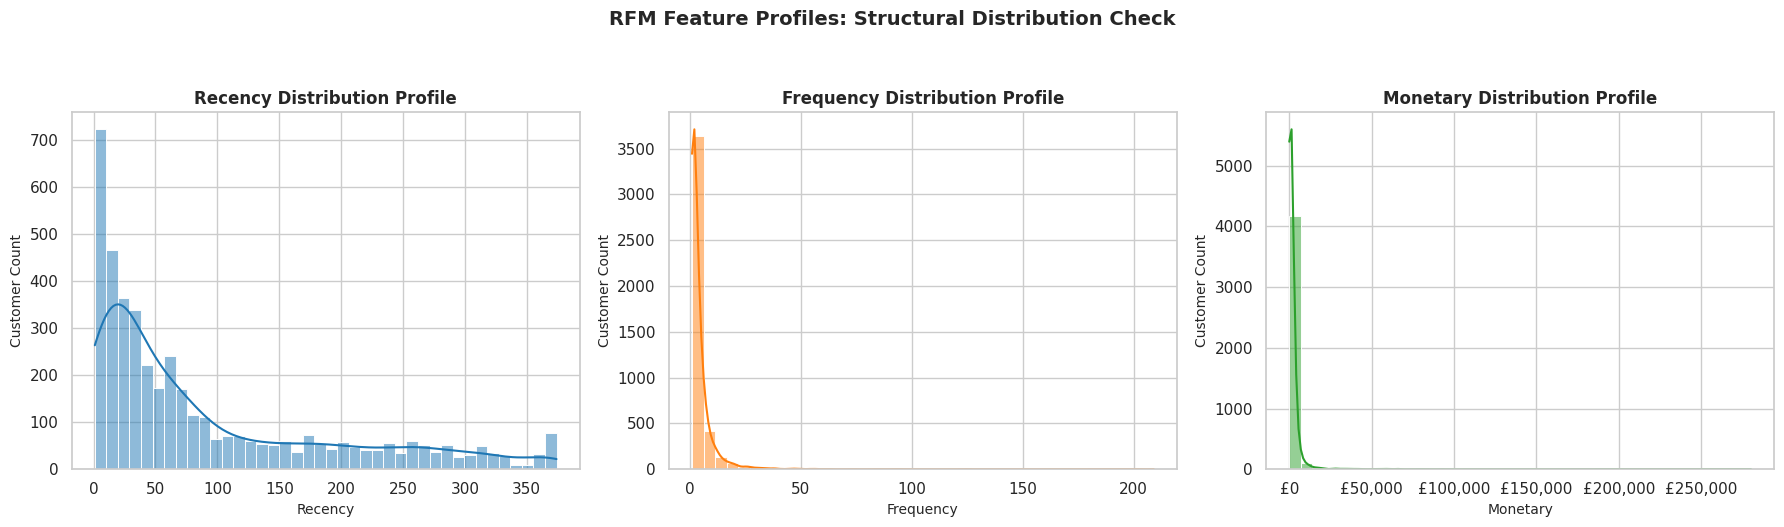

In [37]:
# Distribution Analysis & Outlier Visualisation

import matplotlib.pyplot as plt
import seaborn as sns

# Print skewness metrics to establish statistical ground truth
print("=" * 50)
print("             DATA SKEWNESS COEFFICIENTS             ")
print("=" * 50)
print(f"Recency Skew:   {rfm['Recency'].skew():.2f}")
print(f"Frequency Skew: {rfm['Frequency'].skew():.2f}")
print(f"Monetary Skew:  {rfm['Monetary'].skew():.2f}")
print("=" * 50)
print("Note: Skewness > 1 indicates highly right-skewed data,\nconfirming why we must use robust rank/quintile scoring.")

# Plot the distributions to verify structural variance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
features = ['Recency', 'Frequency', 'Monetary']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (feat, col) in enumerate(zip(features, colors)):
    # Plot histogram with a Kernel Density Estimate (KDE) line
    sns.histplot(rfm[feat], bins=40, kde=True, ax=axes[i], color=col, edgecolor='white')
    axes[i].set_title(f'{feat} Distribution Profile', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('Customer Count', fontsize=10)

    # Format Monetary axis to make it readable if values are huge
    if feat == 'Monetary':
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{int(x):,}"))

plt.suptitle('RFM Feature Profiles: Structural Distribution Check', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

             DATA SKEWNESS COEFFICIENTS             
Recency Skew:   1.25
Frequency Skew: 12.07
Monetary Skew:  19.32
Note: Skewness values > 1 indicate highly right-skewed data.
This statistical skew explicitly proves why we must use robust
rank-based quintiles rather than standard arithmetic means for scoring.


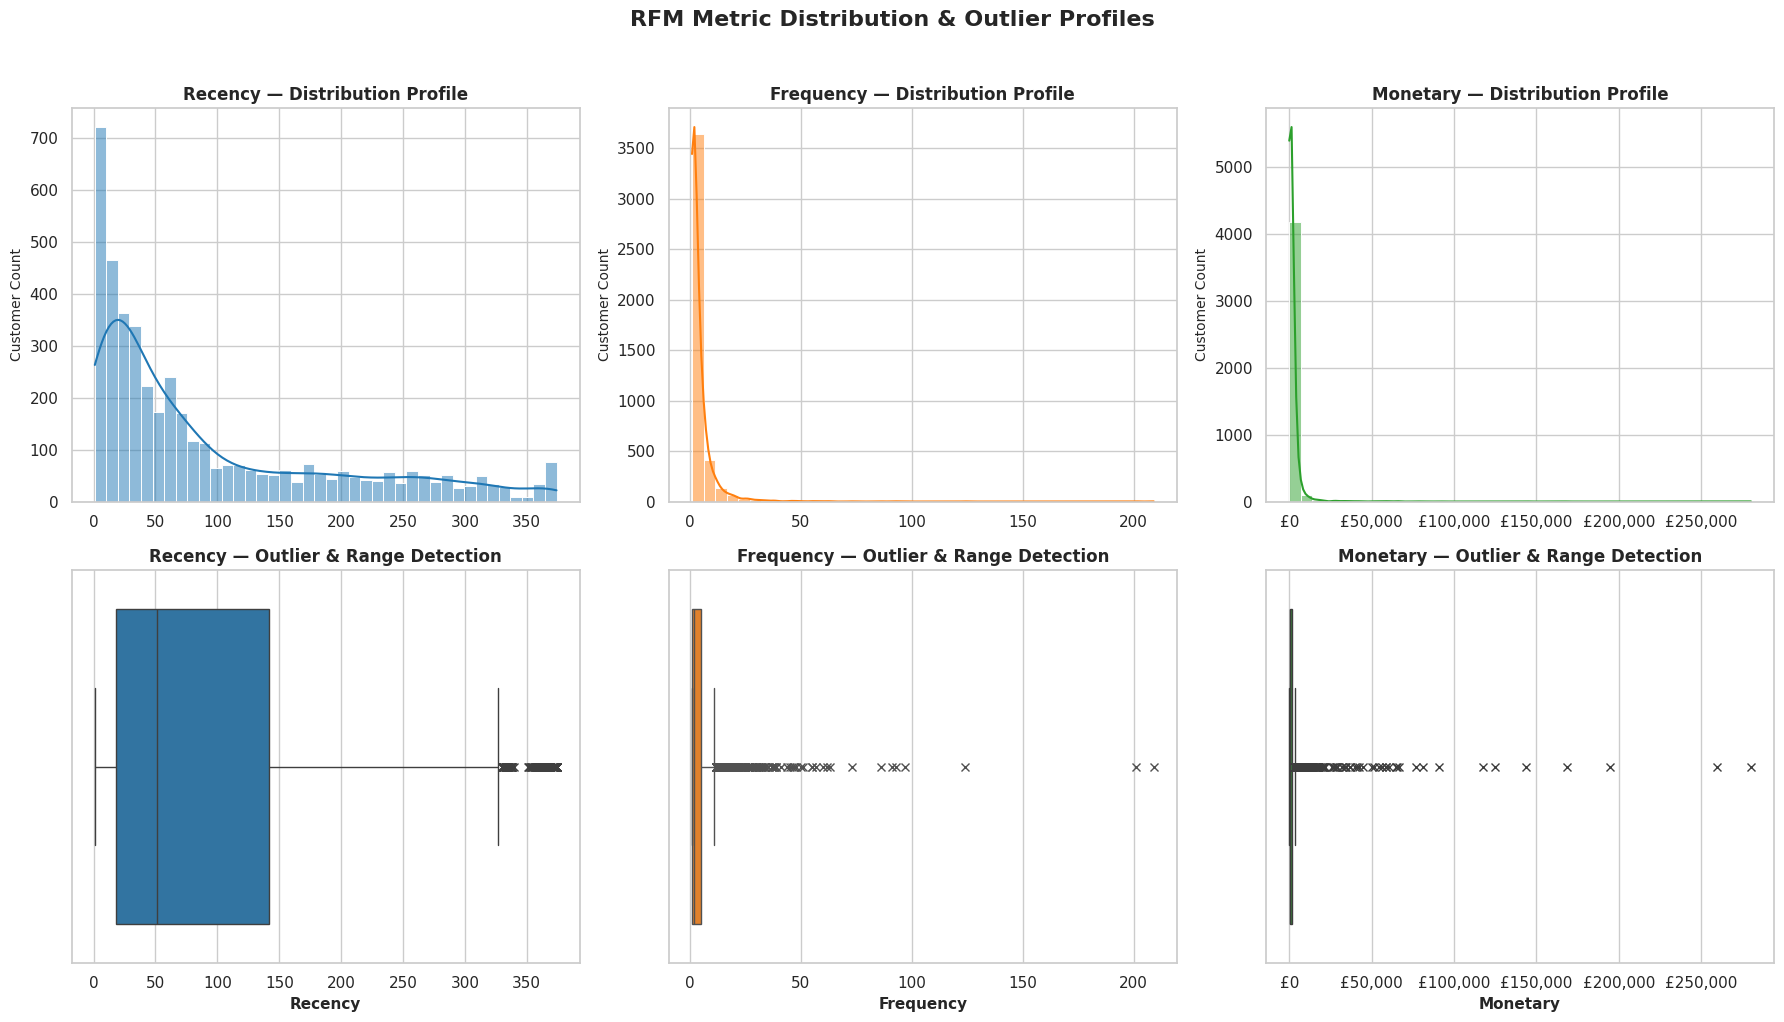

In [38]:
#  Distribution Analysis & Outlier Visualisation

import matplotlib.pyplot as plt
import seaborn as sns

#  Print descriptive skewness coefficients to establish mathematical proof
print("=" * 60)
print("             DATA SKEWNESS COEFFICIENTS             ")
print("=" * 60)
print(f"Recency Skew:   {rfm['Recency'].skew():.2f}")
print(f"Frequency Skew: {rfm['Frequency'].skew():.2f}")
print(f"Monetary Skew:  {rfm['Monetary'].skew():.2f}")
print("=" * 60)
print("Note: Skewness values > 1 indicate highly right-skewed data.\n"
      "This statistical skew explicitly proves why we must use robust\n"
      "rank-based quintiles rather than standard arithmetic means for scoring.")

#  Construct a 2x3 visualization matrix (Histograms on top, Boxplots on bottom)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features = ['Recency', 'Frequency', 'Monetary']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (feat, col) in enumerate(zip(features, colors)):
    # Row 0: Histograms with Kernel Density Estimate (KDE) lines
    sns.histplot(rfm[feat], bins=40, kde=True, ax=axes[0, i], color=col, edgecolor='white')
    axes[0, i].set_title(f'{feat} — Distribution Profile', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('')  # Clear label on top row to avoid clutter
    axes[0, i].set_ylabel('Customer Count', fontsize=10)

    # Row 1: Boxplots to explicitly highlight outliers and quartiles
    sns.boxplot(x=rfm[feat], ax=axes[1, i], color=col, flierprops={"marker": "x", "markerfacecolor": "red"})
    axes[1, i].set_title(f'{feat} — Outlier & Range Detection', fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel(feat, fontsize=11, fontweight='bold')

    # Format Monetary axes into clean British Pounds currency formats
    if feat == 'Monetary':
        axes[0, i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{int(x):,}"))
        axes[1, i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{int(x):,}"))

plt.suptitle('RFM Metric Distribution & Outlier Profiles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [39]:
#   Rule-Based Corporate Segmentation

import pandas as pd

#  Regenerate Quintile Scores safely in the same cell
# Recency: Lower days are better -> Assigns score 5 to the most recent shoppers
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency & Monetary: Higher values are better -> Assigns score 5 to highest volume/spend
# Note: rank(method='first') smoothly handles duplicate values in low-frequency orders
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

#  Concatenate R and F scores into a string map descriptor
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

#  Complete, explicit mapping with ZERO gaps
airtight_segment_map = {
    # Champions: Top tier shoppers (High Recency, High Frequency)
    '55': 'Champions', '54': 'Champions', '45': 'Champions', '44': 'Champions',

    # Loyal Customers: Regular buyers who keep coming back
    '53': 'Loyal Customers', '43': 'Loyal Customers', '35': 'Loyal Customers',
    '34': 'Loyal Customers', '33': 'Loyal Customers', '25': 'Loyal Customers',
    '24': 'Loyal Customers', '23': 'Loyal Customers',

    # New Customers: Just made their first purchase very recently
    '51': 'New Customers', '41': 'New Customers',

    # Promising: Recent shoppers with 2 orders under their belt
    '52': 'Promising', '42': 'Promising', '32': 'Promising',

    # Needs Attention: Average across all metrics
    '31': 'Needs Attention',

    # About to Sleep: Drifting away, low purchase frequency
    '22': 'About to Sleep', '21': 'About to Sleep',

    # At Risk: Haven't visited recently, but used to buy often (High Churn Danger)
    '15': 'At Risk', '14': 'At Risk', '13': 'At Risk',

    # Can't Lose Them: Inactive massive historical spenders
    '12': 'Can\'t Lose Them',

    # Hibernating: Completely dead accounts
    '11': 'Hibernating'
}

#  Apply our fixed map safely
rfm['Customer_Segment'] = rfm['RFM_Segment'].map(airtight_segment_map)

#  Re-run the Audits
print("=" * 60)
print("             FIXED CUSTOMER SEGMENT BREAKDOWN          ")
print("=" * 60)
segment_counts = rfm['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer Segment', 'Headcount']
segment_counts['% of Base'] = ((segment_counts['Headcount'] / len(rfm)) * 100).round(2).astype(str) + '%'
display(segment_counts)

print("\n" + "=" * 60)
print("             FIXED SEGMENT PERFORMANCE MATRIX          ")
print("=" * 60)
segment_analysis = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1).rename(columns={
    'Recency': 'Avg Recency (Days)',
    'Frequency': 'Avg Frequency (Orders)',
    'Monetary': 'Avg Spend (£)'
}).sort_values(by='Avg Spend (£)', ascending=False)
display(segment_analysis)

             FIXED CUSTOMER SEGMENT BREAKDOWN          


,Customer Segment,Headcount,% of Base
0,Loyal Customers,1263,29.11%
1,Champions,1139,26.26%
2,About to Sleep,401,9.24%
3,Promising,365,8.41%
4,Hibernating,364,8.39%
5,Can't Lose Them,300,6.92%
6,At Risk,201,4.63%
7,Needs Attention,164,3.78%
8,New Customers,141,3.25%



             FIXED SEGMENT PERFORMANCE MATRIX          


,Avg Recency (Days),Avg Frequency (Orders),Avg Spend (£)
Customer_Segment,,,
Champions,13.3,10.0,5204.3
Loyal Customers,64.8,3.6,1515.0
At Risk,237.3,3.0,1208.3
Hibernating,278.7,1.0,544.1
Promising,36.3,1.4,513.9
About to Sleep,118.3,1.2,506.8
Needs Attention,53.9,1.0,420.3
Can't Lose Them,277.3,1.1,393.8
New Customers,18.5,1.0,365.1


In [ ]:
#  Cohort Retention Matrix Generation

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#  Isolate the Invoice Month for each transaction
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Identify the Cohort Month (the month of the first purchase) for each customer
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

#  Aggregate data by CohortMonth and InvoiceMonth to count unique returning customers
cohort_data = df_clean.groupby(['CohortMonth', 'InvoiceMonth']).agg(n_customers=('CustomerID', 'nunique')).reset_index()

#  Calculate the Cohort Index (the number of months passed since the first purchase)
cohort_data['CohortIndex'] = (cohort_data['InvoiceMonth'] - cohort_data['CohortMonth']).apply(lambda x: x.n)

# Pivot the table to create a wide matrix layout
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='n_customers')

#  Transform the raw customer counts into percentages relative to the starting Cohort Size (Column 0)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

#  Render Production-Grade Cohort Heatmap

plt.figure(figsize=(16, 10))
sns.heatmap(
    data=retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmax=0.5,  # Caps color saturation at 50% to keep subtle variations visible
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5
)
plt.title('UK Retail Client Cohort Analysis: Monthly User Retention Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Months Elapsed (Cohort Index)', fontsize=12, fontweight='bold')
plt.ylabel('Initial Acquisition Cohort (Month)', fontsize=12, fontweight='bold')
plt.show()

In [ ]:
#  Export Cleaned Datasets for Power BI Modeling

import os

# Define your target output directory in Google Drive
output_dir = '/content/drive/MyDrive/Data_Portfolio/'

# Create the folder safely if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

#  Export the customer-level RFM segment table
rfm.to_csv(os.path.join(output_dir, 'UK_Retail_Customer_Segments.csv'), index=False)

#  Export the transaction-level cohort table
df_clean.to_csv(os.path.join(output_dir, 'UK_Retail_Cleaned_Transactions.csv'), index=False)

print("=" * 50)
print("             EXPORT SUCCESSFUL!                     ")
print("=" * 50)
print(f"1. Customer Segments exported to: {output_dir}UK_Retail_Customer_Segments.csv")
print(f"2. Transaction Ledgers exported to: {output_dir}UK_Retail_Cleaned_Transactions.csv")
print("=" * 50)
print("You are now fully ready to download these CSVs and build the Power BI Dashboard!")

In [ ]:
from google.colab import files

print("Downloading files directly to your computer...")
files.download('/content/drive/MyDrive/Data_Portfolio/UK_Retail_Customer_Segments.csv')
files.download('/content/drive/MyDrive/Data_Portfolio/UK_Retail_Cleaned_Transactions.csv')